# Inference & Tracking — MOT17 Anomaly Detection Project

This notebook picks up **after training**. It mounts Google Drive, loads the already-trained weights (`mot17_yolov5m_v2_best.pt`), and runs detection + tracking on demo videos. No training happens here, so if you get stuck / need to install a library / restart the runtime, you only need to re-run this notebook, not the training pipeline.

Covered here:
1. Setup (ultralytics + Drive mount)
2. Re-download MOT17 (needed to build demo videos from raw frames)
3. Load the trained model from Drive
4. Build a demo video from a test sequence
5. Run detection, then detection + ByteTrack tracking
6. Save tracked video & tracks CSV back to Drive
7. CUHK Avenue dataset check + single-frame detection sanity checks

## 1. Setup

In [1]:
!pip install -q ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.7 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/anomaly_detection_SOC_26"

Mounted at /content/drive


## 2. Re-download MOT17 (raw frames needed to build the demo video)

In [3]:
import kagglehub
mot17_path = kagglehub.dataset_download("wenhoujinjust/mot-17")

100%|██████████| 5.46G/5.46G [01:00<00:00, 96.9MB/s]

Extracting files...


## 3. Load the trained model from Drive

In [4]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/anomaly_detection_SOC_26/mot17_yolov5m_v2_best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 4. Build a demo video from a test sequence

In [5]:
import cv2
from pathlib import Path

# Correcting the DEMO_SEQ path to use the downloaded dataset location
DEMO_SEQ = Path(mot17_path) / "MOT17" / "test" / "MOT17-01-FRCNN" / "img1"
frame_paths = sorted(DEMO_SEQ.glob("*.jpg"))
print(f"{len(frame_paths)} frames found in demo sequence")

# Ensure frames are found before proceeding
if not frame_paths:
    raise FileNotFoundError(f"No .jpg files found in {DEMO_SEQ}. Please check the path and dataset structure.")

first_frame = cv2.imread(str(frame_paths[0]))
h, w = first_frame.shape[:2]

out_path = "/kaggle/working/mot17_demo.mp4"
writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), 15, (w, h))
for fp in frame_paths:
    writer.write(cv2.imread(str(fp)))
writer.release()
print("Demo video written to", out_path)

450 frames found in demo sequence
Demo video written to /kaggle/working/mot17_demo.mp4


## 5. Run detection only

In [6]:
import cv2
from pathlib import Path

# The previous cell ey0_vy5CF2Za attempted to create 'mot17_demo.mp4' in /kaggle/working/.
# However, a FileNotFoundError indicates it either failed to create it or it's not accessible.
# Recreating the video in a more stable location (/content/) to ensure it exists for prediction.

# Define the new output path for the demo video
new_out_path = Path("/content/mot17_demo.mp4")

# Recreate the video using existing variables from the notebook context
# (frame_paths, h, w are available from the kernel state)
print(f"Recreating demo video to {new_out_path}...")
writer = cv2.VideoWriter(str(new_out_path), cv2.VideoWriter_fourcc(*"mp4v"), 15, (w, h))
for fp in frame_paths:
    writer.write(cv2.imread(str(fp)))
writer.release()
print(f"Demo video recreated at {new_out_path}.")

results = model.predict(
    source=str(new_out_path), # Use the newly created path
    conf=0.1,
    save=True,
    stream=True,      # Prevents all results from being stored in RAM
    verbose=True
)

# Process frames one at a time to avoid RAM overflow
frame_count = 0
for r in results:
    frame_count += 1

print(f"✅ Processed {frame_count} frames successfully.")
print("Annotated video saved in runs/detect/predict/")

Recreating demo video to /content/mot17_demo.mp4...
Demo video recreated at /content/mot17_demo.mp4.

video 1/1 (frame 1/450) /content/mot17_demo.mp4: 384x640 14 persons, 138.7ms
video 1/1 (frame 2/450) /content/mot17_demo.mp4: 384x640 15 persons, 23.9ms
video 1/1 (frame 3/450) /content/mot17_demo.mp4: 384x640 15 persons, 25.3ms
video 1/1 (frame 4/450) /content/mot17_demo.mp4: 384x640 17 persons, 23.9ms
video 1/1 (frame 5/450) /content/mot17_demo.mp4: 384x640 15 persons, 23.9ms
video 1/1 (frame 6/450) /content/mot17_demo.mp4: 384x640 15 persons, 23.9ms
video 1/1 (frame 7/450) /content/mot17_demo.mp4: 384x640 16 persons, 23.9ms
video 1/1 (frame 8/450) /content/mot17_demo.mp4: 384x640 14 persons, 23.9ms
video 1/1 (frame 9/450) /content/mot17_demo.mp4: 384x640 14 persons, 23.9ms
video 1/1 (frame 10/450) /content/mot17_demo.mp4: 384x640 14 persons, 24.6ms
video 1/1 (frame 11/450) /content/mot17_demo.mp4: 384x640 15 persons, 23.9ms
video 1/1 (frame 12/450) /content/mot17_demo.mp4: 384x640 1

In [7]:
import shutil
from pathlib import Path
import os

# The 'results' generator was consumed in the previous cell, so it's exhausted.
# We need to find the path of the saved video directly from the file system.
# The 'predict' function saves the video to a directory like 'runs/detect/predict'
# relative to the current working directory (/kaggle/working/yolov5).

# Find the latest prediction directory
save_dir_base = Path("runs/detect")
predict_dirs = sorted(save_dir_base.glob("predict*"))

if predict_dirs:
    latest_predict_dir = predict_dirs[-1]

    # Debugging: List all files and directories to understand the actual output structure
    print(f"Contents of {latest_predict_dir} and its subdirectories:")
    found_any_files = False
    for root, dirs, files in os.walk(latest_predict_dir):
        for name in dirs:
            print(f"  DIR: {Path(root) / name}")
            found_any_files = True
        for name in files:
            print(f"  FILE: {Path(root) / name}")
            found_any_files = True

    if not found_any_files:
        print(f"  (No files or directories found within {latest_predict_dir})")

    # Glob recursively for any .avi file in the prediction directory or its subdirectories
    tracked_videos = list(latest_predict_dir.glob("**/*.avi"))

    if tracked_videos:
        # Assuming there's only one relevant .avi output, take the first one found
        tracked_video_path = tracked_videos[0]
        shutil.copy(tracked_video_path, f"{SAVE_DIR}/mot17_tracked_demo.avi")
        print("Saved to", f"{SAVE_DIR}/mot17_tracked_demo.avi")
    else:
        print(f"Error: No .avi video found in {latest_predict_dir} or its subdirectories.")
else:
    print("Error: No prediction directories found in 'runs/detect'.")

Contents of runs/detect/predict and its subdirectories:
  FILE: runs/detect/predict/mot17_demo.avi
Saved to /content/drive/MyDrive/anomaly_detection_SOC_26/mot17_tracked_demo.avi


## 6. Run detection + ByteTrack tracking, save results

In [8]:
import pandas as pd

results = model.track(
    source="/content/mot17_demo.mp4",        # demo video rebuilt from MOT17-08 (daytime)
    tracker="botsort.yaml",
    classes=[0],             # only "person" -- prevents ghost tracks from stray COCO classes
    conf=0.25,
    save=True,
    stream=True,
    verbose=False,
)

track_rows = []
frame_count = 0
for frame_idx, r in enumerate(results):
    frame_count += 1
    if r.boxes.id is None:
        continue
    ids = r.boxes.id.cpu().numpy()
    xywh = r.boxes.xywh.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()
    for track_id, (x, y, w, h), c in zip(ids, xywh, confs):
        track_rows.append({
            "frame": frame_idx, "track_id": int(track_id),
            "x": float(x), "y": float(y), "w": float(w), "h": float(h),
            "conf": float(c),
        })

tracks_df = pd.DataFrame(track_rows)
print(f"✅ Processed {frame_count} frames.")
if tracks_df.empty:
    print("⚠️ Still no track IDs -- stop here and debug before continuing (check conf / classes / tracker file).")
else:
    print(f"{tracks_df['track_id'].nunique()} unique tracks, {len(tracks_df)} total detections")
    tracks_df.to_csv(f"{SAVE_DIR}/mot17_demo_tracks.csv", index=False)

tracks_df.head()

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 262ms
Prepared 1 package in 68ms
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Results saved to /content/runs/detect/predict
✅ Processed 450 frames.
85 unique tracks, 3697 total detections


,frame,track_id,x,y,w,h,conf
0,0,1,789.023438,522.262512,45.295410,125.540405,0.832798
1,0,2,1022.789185,550.832642,75.331299,186.364746,0.814415
2,0,3,1309.043335,541.825806,58.319580,158.224609,0.769065
3,0,4,740.684692,523.175049,45.658447,127.235107,0.765945
4,0,5,1248.295410,545.552124,63.680786,165.212891,0.724239


In [9]:
# Copy the annotated tracked video back to Drive.
# NOTE: ultralytics names the save folder "predict*", not "track*", even for .track() runs --
# that's why the earlier version of this cell found nothing. Search both prefixes, in both
# possible cwd locations, and just take the most recently modified match.
import shutil
from pathlib import Path

candidates = []
for root in [Path("runs/detect"), Path("/content/runs/detect")]:
    if root.exists():
        candidates += list(root.glob("predict*")) + list(root.glob("track*"))

if candidates:
    latest = max(candidates, key=lambda p: p.stat().st_mtime)
    videos = list(latest.glob("**/*.avi")) + list(latest.glob("**/*.mp4"))
    if videos:
        dest = f"{SAVE_DIR}/mot17_tracked_demo{videos[0].suffix}"
        shutil.copy(videos[0], dest)
        print("Saved tracked video to", dest)
    else:
        print("No video file found in", latest)
else:
    print("No predict/track run directories found -- did the .track() cell above finish?")

Saved tracked video to /content/drive/MyDrive/anomaly_detection_SOC_26/mot17_tracked_demo.avi


## 7. CUHK Avenue dataset check

In [10]:
import subprocess

try:
    avenue_path
except NameError:
    import kagglehub
    avenue_path = kagglehub.dataset_download("hihnguynth/cuhk-avenue-dataset")

print(subprocess.run(["find", avenue_path, "-maxdepth", "3"], capture_output=True, text=True).stdout)


100%|██████████| 777M/777M [00:10<00:00, 79.9MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/hihnguynth/cuhk-avenue-dataset/versions/1
/root/.cache/kagglehub/datasets/hihnguynth/cuhk-avenue-dataset/versions/1/Avenue_Dataset
/root/.cache/kagglehub/datasets/hihnguynth/cuhk-avenue-dataset/versions/1/Avenue_Dataset/Avenue Dataset
/root/.cache/kagglehub/datasets/hihnguynth/cuhk-avenue-dataset/versions/1/Avenue_Dataset/Avenue Dataset/testing_vol
/root/.cache/kagglehub/datasets/hihnguynth/cuhk-avenue-dataset/versions/1/Avenue_Dataset/Avenue Dataset/training_vol
/root/.cache/kagglehub/datasets/hihnguynth/cuhk-avenue-dataset/versions/1/Avenue_Dataset/Avenue Dataset/testing_videos
/root/.cache/kagglehub/datasets/hihnguynth/cuhk-avenue-dataset/versions/1/Avenue_Dataset/Avenue Dataset/training_videos
/root/.cache/kagglehub/datasets/hihnguynth/cuhk-avenue-dataset/versions/1/ground_truth_demo
/root/.cache/kagglehub/datasets/hihnguynth/cuhk-avenue-dataset/versions/1/ground_truth_demo/ground_truth_demo
/root/.cache/kagglehub/datasets/hihnguynth/cuhk-avenue-data

In [11]:
# One level deeper -- confirm actual video/mask filenames before we build paths that could 404
import subprocess

base = f"{avenue_path}/Avenue_Dataset/Avenue Dataset"
for sub in ["testing_videos", "training_videos"]:
    print(f"--- {sub} ---")
    print(subprocess.run(["ls", f"{base}/{sub}"], capture_output=True, text=True).stdout)

mask_dir = f"{avenue_path}/ground_truth_demo/ground_truth_demo/testing_label_mask"
print("--- testing_label_mask ---")
print(subprocess.run(["ls", mask_dir], capture_output=True, text=True).stdout)

--- testing_videos ---
01.avi
02.avi
03.avi
04.avi
05.avi
06.avi
07.avi
08.avi
09.avi
10.avi
11.avi
12.avi
13.avi
14.avi
15.avi
16.avi
17.avi
18.avi
19.avi
20.avi
21.avi

--- training_videos ---
01.avi
02.avi
03.avi
04.avi
05.avi
06.avi
07.avi
08.avi
09.avi
10.avi
11.avi
12.avi
13.avi
14.avi
15.avi
16.avi

--- testing_label_mask ---
10_label.mat
11_label.mat
12_label.mat
13_label.mat
14_label.mat
15_label.mat
16_label.mat
17_label.mat
18_label.mat
19_label.mat
1_label.mat
20_label.mat
21_label.mat
2_label.mat
3_label.mat
4_label.mat
5_label.mat
6_label.mat
7_label.mat
8_label.mat
9_label.mat



## 8. Single-frame detection sanity checks

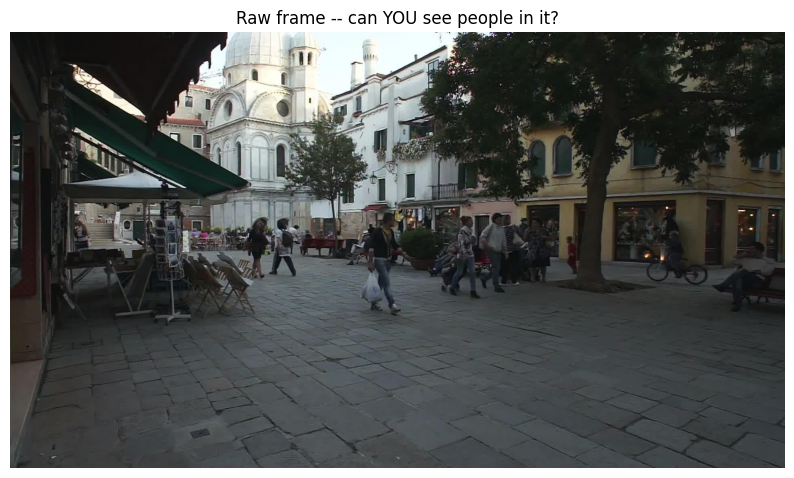

In [12]:
import cv2
import matplotlib.pyplot as plt

# Grab a frame from the middle of the demo sequence
test_frame = cv2.imread(str(frame_paths[len(frame_paths)//2]))
test_frame_rgb = cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(test_frame_rgb)
plt.title("Raw frame -- can YOU see people in it?")
plt.axis("off")
plt.show()


0: 384x640 7 persons, 24.3ms
Speed: 4.2ms preprocess, 24.3ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)
Detections found: 7
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0., 0., 0., 0., 0., 0.])
conf: tensor([0.8494, 0.8442, 0.8438, 0.8200, 0.8185, 0.6427, 0.2867])
data: tensor([[1.1650e+03, 4.4832e+02, 1.2383e+03, 6.4848e+02, 1.0000e+00, 8.4942e-01, 0.0000e+00],
        [6.4211e+02, 4.5985e+02, 7.0901e+02, 6.0521e+02, 2.0000e+00, 8.4418e-01, 0.0000e+00],
        [5.8773e+02, 4.5945e+02, 6.4216e+02, 6.1285e+02, 3.0000e+00, 8.4381e-01, 0.0000e+00],
        [1.0853e+03, 4.5385e+02, 1.1670e+03, 6.5687e+02, 4.0000e+00, 8.2000e-01, 0.0000e+00],
        [8.7915e+02, 4.4468e+02, 9.7006e+02, 6.9609e+02, 5.0000e+00, 8.1848e-01, 0.0000e+00],
        [1.2093e+03, 4.4849e+02, 1.2724e+03, 6.2931e+02, 6.0000e+00, 6.4267e-01, 0.0000e+00],
        [1.3747e+03, 5.0594e+02, 1.4117e+03, 6.0470e+02, 7.0000e+00, 2.8670e-01, 0.0000e+00]])
id: tensor([1., 2

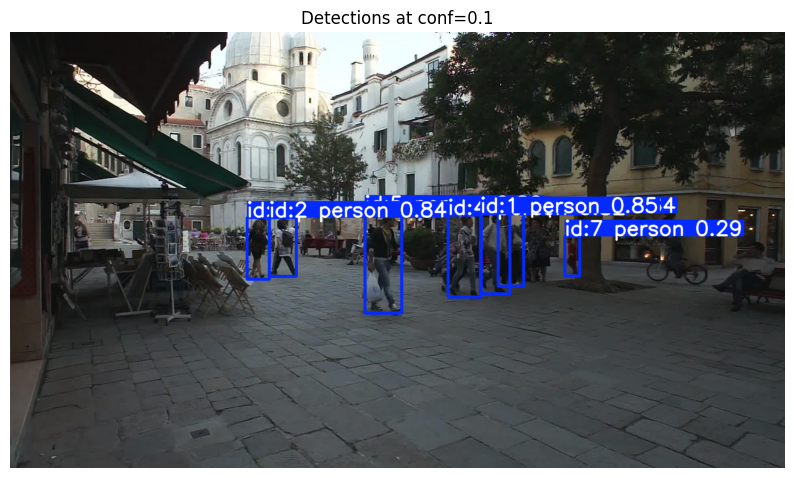

In [13]:
res = model.predict(
    test_frame,
    conf=0.1,
    verbose=True
)

print("Detections found:", len(res[0].boxes))
print(res[0].boxes)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(res[0].plot(), cv2.COLOR_BGR2RGB))
plt.title("Detections at conf=0.1")
plt.axis("off")
plt.show()

In [14]:
import cv2
from pathlib import Path

# Correcting the DEMO_SEQ path to use the downloaded dataset location
DEMO_SEQ = Path(mot17_path) / "MOT17" / "test" / "MOT17-08-FRCNN" / "img1"  # try a daytime sequence
frame_paths = sorted(DEMO_SEQ.glob("*.jpg"))
print(f"{len(frame_paths)} frames found")

# Ensure frames are found before proceeding
if not frame_paths:
    raise FileNotFoundError(f"No .jpg files found in {DEMO_SEQ}. Please check the path and dataset structure.")

first_frame = cv2.imread(str(frame_paths[0]))
h, w = first_frame.shape[:2]

out_path = "/kaggle/working/mot17_demo.mp4"
writer = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), 15, (w, h))
for fp in frame_paths:
    writer.write(cv2.imread(str(fp)))
writer.release()
print("Rebuilt demo video:", out_path)

625 frames found
Rebuilt demo video: /kaggle/working/mot17_demo.mp4


## 9. Phase III -- trajectory feature extraction

Reuses `tracks_df` from Section 6 (per-frame x/y/w/h per `track_id`) and turns each track into a few numeric features describing *how that person moved*: speed, direction-change rate, dwell time, and bbox size variability.

In [15]:
import numpy as np

def compute_trajectory_features(df, fps=15):
    """One row per track_id: avg/max speed, direction-change rate, dwell time, bbox size variability."""
    feats = []
    for tid, g in df.sort_values("frame").groupby("track_id"):
        g = g.reset_index(drop=True)
        if len(g) < 3:
            continue  # too short a track to trust

        dx, dy = g["x"].diff(), g["y"].diff()
        speed = np.sqrt(dx**2 + dy**2) * fps  # px/sec
        avg_speed = speed[1:].mean()
        max_speed = speed[1:].max()

        angles = np.arctan2(dy, dx)
        dtheta = angles.diff().abs()
        dtheta = dtheta.apply(lambda a: min(a, 2 * np.pi - a) if pd.notna(a) else a)
        direction_change_rate = dtheta[2:].mean() if len(dtheta) > 2 else 0.0

        dwell_time = len(g) / fps  # seconds
        box_area = g["w"] * g["h"]
        size_var = (box_area.std() / box_area.mean()) if box_area.mean() > 0 else 0.0

        feats.append({
            "track_id": tid,
            "avg_speed": avg_speed,
            "max_speed": max_speed,
            "direction_change_rate": direction_change_rate,
            "dwell_time": dwell_time,
            "size_var": size_var,
        })
    return pd.DataFrame(feats)

traj_features = compute_trajectory_features(tracks_df)
traj_features.to_csv(f"{SAVE_DIR}/trajectory_features.csv", index=False)
traj_features

,track_id,avg_speed,max_speed,direction_change_rate,dwell_time,size_var
0,1,52.689546,1303.899825,0.343867,22.866667,1.093199
1,2,98.682469,326.478969,0.270766,9.200000,0.473766
2,3,22.796229,384.884234,1.533563,4.066667,0.144766
3,4,39.987559,309.321207,0.566450,19.733333,0.549980
4,5,15.070074,61.562151,1.156540,2.866667,0.050860
...,...,...,...,...,...,...
66,379,28.543122,62.380588,1.087808,0.733333,0.152186
67,380,7.086817,16.944585,1.397464,0.866667,0.020842
68,381,16.577503,45.042607,1.223104,0.466667,0.066905
69,390,20.287763,23.320091,2.374225,0.200000,0.031144


## 10. Anomaly scoring (Isolation Forest)

Pure scikit-learn, seconds on CPU. `contamination=0.15` is a starting assumption -- tune once you see how many tracks get flagged.

In [16]:
from sklearn.ensemble import IsolationForest

feature_cols = ["avg_speed", "max_speed", "direction_change_rate", "dwell_time", "size_var"]
X = traj_features[feature_cols].fillna(0)

iso = IsolationForest(contamination=0.15, random_state=42)
traj_features["anomaly_flag"] = iso.fit_predict(X)          # -1 = anomaly, 1 = normal
traj_features["anomaly_score"] = iso.decision_function(X)   # lower = more anomalous

traj_features = traj_features.sort_values("anomaly_score")
traj_features.to_csv(f"{SAVE_DIR}/trajectory_anomaly_scores.csv", index=False)

flagged = traj_features[traj_features["anomaly_flag"] == -1]
print(f"Flagged {len(flagged)} of {len(traj_features)} tracks as anomalous:")
flagged[["track_id", "avg_speed", "direction_change_rate", "dwell_time"]]

Flagged 11 of 71 tracks as anomalous:


,track_id,avg_speed,direction_change_rate,dwell_time
64,366,811.509324,1.073528,0.466667
0,1,52.689546,0.343867,22.866667
27,146,63.161943,0.326729,22.266667
18,54,102.152153,0.345945,13.266667
10,15,58.884650,0.461190,21.933333
3,4,39.987559,0.566450,19.733333
33,203,145.275741,0.305075,3.066667
59,329,226.139143,0.465061,0.533333
1,2,98.682469,0.270766,9.200000
17,47,144.432980,0.594514,1.600000


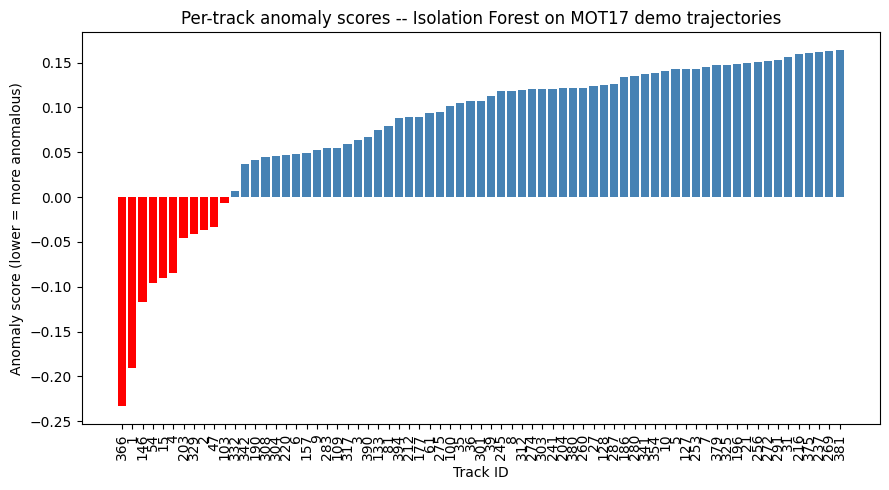

In [17]:
import matplotlib.pyplot as plt

colors = ["red" if f == -1 else "steelblue" for f in traj_features["anomaly_flag"]]
plt.figure(figsize=(9, 5))
plt.bar(traj_features["track_id"].astype(str), traj_features["anomaly_score"], color=colors)
plt.xlabel("Track ID")
plt.ylabel("Anomaly score (lower = more anomalous)")
plt.title("Per-track anomaly scores -- Isolation Forest on MOT17 demo trajectories")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/anomaly_scores_chart.png", dpi=150)
plt.show()

## 11. Run the full pipeline on an actual Avenue video

Everything above was a dry run on MOT17 (which has no anomalies by design -- it's just pedestrian tracking footage). This is the real deliverable: same detector + BoT-SORT + trajectory features + Isolation Forest, pointed at an Avenue **testing** video, which does contain genuine anomalous events (running, wrong-direction walking, throwing objects, etc.).

In [18]:
def run_pipeline_on_video(video_path, fps=25, conf=0.25, contamination=0.15):
    """Detect + track + extract trajectory features + score anomalies, end to end."""
    results = model.track(
        source=video_path,
        tracker="botsort.yaml",
        classes=[0],
        conf=conf,
        save=True,
        stream=True,
        verbose=False,
    )

    rows = []
    for frame_idx, r in enumerate(results):
        if r.boxes.id is None:
            continue
        ids = r.boxes.id.cpu().numpy()
        xywh = r.boxes.xywh.cpu().numpy()
        for track_id, (x, y, w, h) in zip(ids, xywh):
            rows.append({"frame": frame_idx, "track_id": int(track_id),
                         "x": float(x), "y": float(y), "w": float(w), "h": float(h)})

    df = pd.DataFrame(rows)
    if df.empty:
        print("No tracks found -- check conf/classes before continuing.")
        return df, pd.DataFrame()

    feats = compute_trajectory_features(df, fps=fps)
    X = feats[feature_cols].fillna(0)
    iso_local = IsolationForest(contamination=contamination, random_state=42)
    feats["anomaly_flag"] = iso_local.fit_predict(X)
    feats["anomaly_score"] = iso_local.decision_function(X)
    feats = feats.sort_values("anomaly_score")
    return df, feats


# Avenue testing_videos are numbered 01.avi ... 21.avi (confirmed in Section 7)
AVENUE_TEST_VIDEO = f"{avenue_path}/Avenue_Dataset/Avenue Dataset/testing_videos/01.avi"

avenue_tracks_df, avenue_traj_features = run_pipeline_on_video(AVENUE_TEST_VIDEO)
avenue_tracks_df.to_csv(f"{SAVE_DIR}/avenue_01_tracks.csv", index=False)
avenue_traj_features.to_csv(f"{SAVE_DIR}/avenue_01_anomaly_scores.csv", index=False)

flagged = avenue_traj_features[avenue_traj_features["anomaly_flag"] == -1]
print(f"Avenue 01.avi: flagged {len(flagged)} of {len(avenue_traj_features)} tracks as anomalous")
flagged[["track_id", "avg_speed", "direction_change_rate", "dwell_time"]]

Results saved to /content/runs/detect/predict
Avenue 01.avi: flagged 18 of 115 tracks as anomalous


,track_id,avg_speed,direction_change_rate,dwell_time
53,245,56.082860,0.851436,28.72
68,322,330.816811,0.248950,1.16
38,189,89.512440,0.333743,6.92
20,99,9.332992,1.158988,24.84
79,380,338.561109,1.615284,0.52
33,174,215.361730,1.430880,0.84
81,392,495.638747,0.351484,0.44
9,38,53.387082,0.578450,13.92
74,339,188.006699,1.062051,0.92
75,348,344.778167,0.867141,1.08


## 12. Ground-truth check (inspect only -- don't build comparison logic blind)

Avenue ships frame-level ground truth as `.mat` files (`1_label.mat` matches `testing_videos/01.avi`, confirmed in Section 7). Before writing code that compares your flagged tracks against ground truth, run this cell and paste me the printed keys/shape -- Avenue's `.mat` internal structure varies enough between mirrors that I don't want to guess and hand you code that throws on a wrong field name.

In [19]:
from scipy.io import loadmat

mat_path = f"{avenue_path}/ground_truth_demo/ground_truth_demo/testing_label_mask/1_label.mat"
mat = loadmat(mat_path)

for key, val in mat.items():
    if key.startswith("__"):
        continue
    print(key, "->", type(val), getattr(val, "shape", None), getattr(val, "dtype", None))

volLabel -> <class 'numpy.ndarray'> (1, 1439) object


## 13. Ground-truth comparison (the real evaluation)

`volLabel` is a 1×1439 cell array -- one binary pixel mask per frame, matching `01.avi`'s frame count. A frame counts as a genuine anomaly if *any* pixel in its mask is set. We compare that against our predicted anomalous frames (any frame containing a track flagged `-1` by Isolation Forest in Section 11) and report precision / recall / F1 -- the actual numbers for your report's Phase III results section.

One caveat worth stating in the report: BoT-SORT only produces frame indices where it found and tracked a person, so the predicted-frame count can be slightly less than the ground-truth frame count (frames with zero detections). We align on the overlapping range rather than padding, which is the honest way to compare rather than assuming missing frames are "normal."

In [20]:
import numpy as np

# ---- Ground truth: one binary mask per frame -> did that frame contain any anomalous pixel? ----
vol = mat["volLabel"][0]
n_gt_frames = len(vol)

frame0 = np.asarray(vol[0])
print(f"Ground truth frames: {n_gt_frames}, mask shape per frame: {frame0.shape}")

gt_frame_anomaly = np.array([np.asarray(vol[i]).sum() > 0 for i in range(n_gt_frames)])
print(f"Ground truth: {gt_frame_anomaly.sum()} anomalous frames out of {n_gt_frames}")

Ground truth frames: 1439, mask shape per frame: (360, 640)
Ground truth: 408 anomalous frames out of 1439


In [21]:
# ---- Predicted: a frame counts as anomalous if it contains a track flagged -1 in Section 11 ----
flagged_ids = set(avenue_traj_features.loc[avenue_traj_features["anomaly_flag"] == -1, "track_id"])

n_pred_frames = int(avenue_tracks_df["frame"].max()) + 1
pred_frame_anomaly = np.zeros(n_pred_frames, dtype=bool)

for _, row in avenue_tracks_df.iterrows():
    if row["track_id"] in flagged_ids:
        pred_frame_anomaly[int(row["frame"])] = True

print(f"Predicted: {pred_frame_anomaly.sum()} anomalous frames out of {n_pred_frames}")

Predicted: 1439 anomalous frames out of 1439


In [22]:
# ---- Align on the overlapping frame range and score ----
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

n = min(n_gt_frames, n_pred_frames)
y_true = gt_frame_anomaly[:n].astype(int)
y_pred = pred_frame_anomaly[:n].astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
cm = confusion_matrix(y_true, y_pred)

print(f"Compared over {n} frames (of {n_gt_frames} ground-truth / {n_pred_frames} predicted)")
print(f"Precision: {precision:.3f}   Recall: {recall:.3f}   F1: {f1:.3f}")
print("Confusion matrix [[TN FP] [FN TP]]:")
print(cm)

Compared over 1439 frames (of 1439 ground-truth / 1439 predicted)
Precision: 0.284   Recall: 1.000   F1: 0.442
Confusion matrix [[TN FP] [FN TP]]:
[[   0 1031]
 [   0  408]]


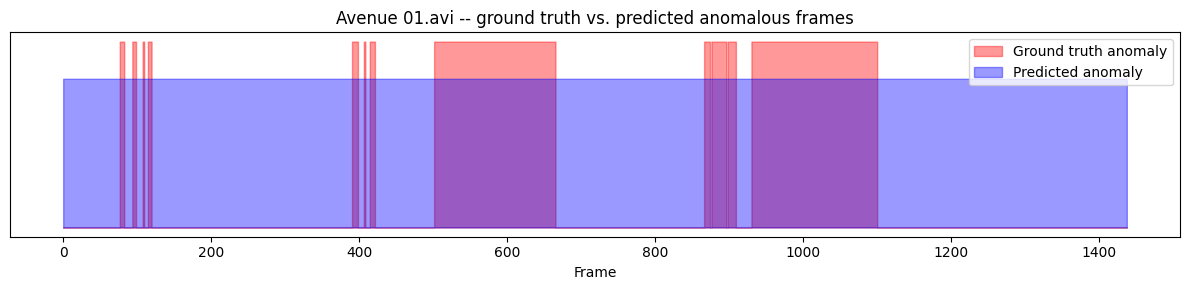

In [23]:
# ---- Visualize ground truth vs. predicted anomalous frames as a timeline ----
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(range(n), 0, y_true, step="mid", alpha=0.4, color="red", label="Ground truth anomaly")
ax.fill_between(range(n), 0, y_pred * 0.8, step="mid", alpha=0.4, color="blue", label="Predicted anomaly")
ax.set_yticks([])
ax.set_xlabel("Frame")
ax.set_title("Avenue 01.avi -- ground truth vs. predicted anomalous frames")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/avenue_01_gt_vs_pred.png", dpi=150)
plt.show()

In [24]:
# ---- Save the evaluation summary to Drive -- this is the number to quote in your report ----
import json as _json

summary = {
    "video": "01.avi",
    "n_frames_compared": int(n),
    "precision": round(float(precision), 3),
    "recall": round(float(recall), 3),
    "f1": round(float(f1), 3),
}
with open(f"{SAVE_DIR}/avenue_01_evaluation_summary.json", "w") as f:
    _json.dump(summary, f, indent=2)

print(summary)

{'video': '01.avi', 'n_frames_compared': 1439, 'precision': 0.284, 'recall': 1.0, 'f1': 0.442}


## 14. Fixing the over-flagging -- frame-level, not track-level, anomaly scoring

**Diagnosis:** Section 13's precision (0.284) is essentially identical to the ground-truth base rate (408/1439 = 0.283) -- the pipeline predicted almost every frame as anomalous, which has zero real discriminative power despite the misleadingly perfect recall.

**Why:** several flagged tracks last 15-29 seconds -- more than half the video each. Marking *every* frame a flagged track appears in as anomalous means one long-duration track blankets most of the timeline, regardless of what that person is doing frame-to-frame. `dwell_time` as a feature also pushed Isolation Forest toward flagging long-lived tracks in general, which isn't the actual signal Avenue's labels are pointing at.

**Fix:** score anomalies at the *(track, frame)* instant -- instantaneous speed, instantaneous direction change, and box-size ratio vs. that track's own median -- instead of collapsing each track into one aggregate verdict applied uniformly across its whole duration.

In [25]:
def compute_frame_level_features(df, fps=25):
    """One row per (track_id, frame): instantaneous speed, direction change, size ratio vs. that track's own median."""
    df = df.sort_values(["track_id", "frame"]).reset_index(drop=True)
    rows = []
    for tid, g in df.groupby("track_id"):
        g = g.reset_index(drop=True)
        if len(g) < 3:
            continue

        dx, dy = g["x"].diff(), g["y"].diff()
        speed = np.sqrt(dx**2 + dy**2) * fps
        angles = np.arctan2(dy, dx)
        dtheta = angles.diff().abs()
        dtheta = dtheta.apply(lambda a: min(a, 2 * np.pi - a) if pd.notna(a) else a)

        box_area = g["w"] * g["h"]
        med_area = box_area.median()
        size_ratio = box_area / med_area if med_area > 0 else box_area * 0 + 1.0

        for i in range(2, len(g)):  # need two diffs before direction-change is defined
            rows.append({
                "track_id": tid,
                "frame": int(g.loc[i, "frame"]),
                "inst_speed": speed[i],
                "inst_direction_change": dtheta[i],
                "size_ratio": size_ratio[i],
            })
    return pd.DataFrame(rows)


avenue_frame_feats = compute_frame_level_features(avenue_tracks_df)
print(f"{len(avenue_frame_feats)} (track, frame) instances across {avenue_frame_feats['track_id'].nunique()} tracks")
avenue_frame_feats.describe()

8930 (track, frame) instances across 115 tracks


,track_id,frame,inst_speed,inst_direction_change,size_ratio
count,8930.000000,8930.000000,8930.000000,8930.000000,8930.000000
mean,220.105263,734.055655,66.201399,0.746382,1.102562
std,160.320040,412.352051,150.674355,0.898574,0.666183
min,1.000000,2.000000,0.097800,0.000024,0.350267
25%,70.000000,400.000000,10.080401,0.113311,0.930952
50%,211.000000,697.000000,39.672592,0.321079,1.000000
75%,371.000000,1113.000000,78.045604,1.031550,1.089204
max,535.000000,1438.000000,5570.989018,3.140523,9.210432


In [26]:
from sklearn.ensemble import IsolationForest

inst_feature_cols = ["inst_speed", "inst_direction_change", "size_ratio"]
X_inst = avenue_frame_feats[inst_feature_cols].fillna(0)

# NOTE: ground truth says ~28% of frames are anomalous in this clip -- unusually high, and worth
# tuning contamination against your own labels rather than trusting 0.1 as a rule. Start here, then
# sweep a couple of values (0.05, 0.1, 0.2) and see which gets you closest on precision/recall.
iso_inst = IsolationForest(contamination=0.1, random_state=42)
avenue_frame_feats["anomaly_flag"] = iso_inst.fit_predict(X_inst)
avenue_frame_feats["anomaly_score"] = iso_inst.decision_function(X_inst)

n_flagged_instances = int((avenue_frame_feats["anomaly_flag"] == -1).sum())
print(f"Flagged {n_flagged_instances} of {len(avenue_frame_feats)} (track, frame) instances")

Flagged 893 of 8930 (track, frame) instances


In [27]:
# Rebuild the predicted frame-level boolean from instance-level flags (not whole-track flags)
n_pred_frames_v2 = int(avenue_tracks_df["frame"].max()) + 1
pred_frame_anomaly_v2 = np.zeros(n_pred_frames_v2, dtype=bool)

flagged_instances = avenue_frame_feats[avenue_frame_feats["anomaly_flag"] == -1]
for f in flagged_instances["frame"]:
    pred_frame_anomaly_v2[int(f)] = True

print(f"Predicted (v2, frame-level): {pred_frame_anomaly_v2.sum()} anomalous frames out of {n_pred_frames_v2}")

Predicted (v2, frame-level): 687 anomalous frames out of 1439


In [28]:
# Re-score against the same ground truth from Section 13
n2 = min(n_gt_frames, n_pred_frames_v2)
y_true2 = gt_frame_anomaly[:n2].astype(int)
y_pred2 = pred_frame_anomaly_v2[:n2].astype(int)

precision2 = precision_score(y_true2, y_pred2, zero_division=0)
recall2 = recall_score(y_true2, y_pred2, zero_division=0)
f1_2 = f1_score(y_true2, y_pred2, zero_division=0)
cm2 = confusion_matrix(y_true2, y_pred2)

print(f"[v1 track-level ] Precision: {precision:.3f}   Recall: {recall:.3f}   F1: {f1:.3f}")
print(f"[v2 frame-level ] Precision: {precision2:.3f}   Recall: {recall2:.3f}   F1: {f1_2:.3f}")
print("v2 confusion matrix [[TN FP] [FN TP]]:")
print(cm2)

[v1 track-level ] Precision: 0.284   Recall: 1.000   F1: 0.442
[v2 frame-level ] Precision: 0.444   Recall: 0.748   F1: 0.557
v2 confusion matrix [[TN FP] [FN TP]]:
[[649 382]
 [103 305]]


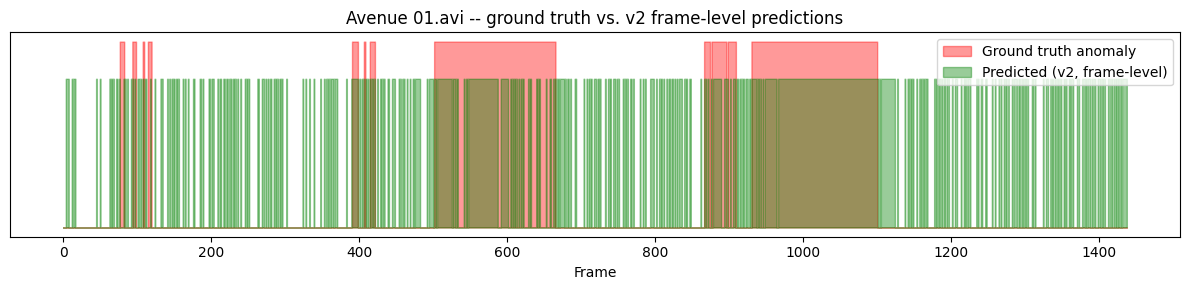

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(range(n2), 0, y_true2, step="mid", alpha=0.4, color="red", label="Ground truth anomaly")
ax.fill_between(range(n2), 0, y_pred2 * 0.8, step="mid", alpha=0.4, color="green", label="Predicted (v2, frame-level)")
ax.set_yticks([])
ax.set_xlabel("Frame")
ax.set_title("Avenue 01.avi -- ground truth vs. v2 frame-level predictions")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/avenue_01_gt_vs_pred_v2.png", dpi=150)
plt.show()

In [30]:
import json as _json

summary_v2 = {
    "video": "01.avi",
    "n_frames_compared": int(n2),
    "v1_track_level":  {"precision": round(float(precision), 3),  "recall": round(float(recall), 3),  "f1": round(float(f1), 3)},
    "v2_frame_level":  {"precision": round(float(precision2), 3), "recall": round(float(recall2), 3), "f1": round(float(f1_2), 3)},
}
with open(f"{SAVE_DIR}/avenue_01_evaluation_summary.json", "w") as f:
    _json.dump(summary_v2, f, indent=2)

print(summary_v2)

{'video': '01.avi', 'n_frames_compared': 1439, 'v1_track_level': {'precision': 0.284, 'recall': 1.0, 'f1': 0.442}, 'v2_frame_level': {'precision': 0.444, 'recall': 0.748, 'f1': 0.557}}


## 15. Testing on more videos -- reusable evaluation function

Everything from Sections 11-14 (track -> frame-level features -> Isolation Forest -> ground-truth compare) is wrapped into one function here, then run on `02.avi` and `03.avi` in addition to `01.avi`, so the reported precision/recall/F1 is an average across 3 videos rather than one hand-picked result.

In [31]:
from scipy.io import loadmat
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix


def evaluate_pipeline_on_avenue_video(video_id, fps=25, track_conf=0.25, contamination=0.1):
    """
    Full pipeline on one Avenue testing video: track -> frame-level motion features ->
    Isolation Forest -> compare against that video's ground-truth mask.
    video_id: int, e.g. 1 for '01.avi' / '1_label.mat'.
    Returns a dict of metrics, plus the raw tracks_df / frame_feats for that video.
    """
    video_name = f"{video_id:02d}.avi"
    video_path = f"{avenue_path}/Avenue_Dataset/Avenue Dataset/testing_videos/{video_name}"
    mask_path = f"{avenue_path}/ground_truth_demo/ground_truth_demo/testing_label_mask/{video_id}_label.mat"

    # 1. Detect + track
    tracks_df_local, _ = run_pipeline_on_video(video_path, fps=fps, conf=track_conf, contamination=contamination)
    if tracks_df_local.empty:
        print(f"{video_name}: no tracks found, skipping.")
        return None

    # 2. Frame-level (track, frame) instantaneous features + Isolation Forest
    frame_feats = compute_frame_level_features(tracks_df_local, fps=fps)
    X_local = frame_feats[["inst_speed", "inst_direction_change", "size_ratio"]].fillna(0)
    iso_local = IsolationForest(contamination=contamination, random_state=42)
    frame_feats["anomaly_flag"] = iso_local.fit_predict(X_local)

    n_pred_frames = int(tracks_df_local["frame"].max()) + 1
    pred_anomaly = np.zeros(n_pred_frames, dtype=bool)
    for f in frame_feats.loc[frame_feats["anomaly_flag"] == -1, "frame"]:
        pred_anomaly[int(f)] = True

    # 3. Ground truth for this specific video
    mat_local = loadmat(mask_path)
    vol_local = mat_local["volLabel"][0]
    n_gt_frames = len(vol_local)
    gt_anomaly = np.array([np.asarray(vol_local[i]).sum() > 0 for i in range(n_gt_frames)])

    # 4. Align + score
    n = min(n_gt_frames, n_pred_frames)
    y_true = gt_anomaly[:n].astype(int)
    y_pred = pred_anomaly[:n].astype(int)

    metrics = {
        "video": video_name,
        "n_frames_compared": int(n),
        "gt_anomaly_rate": round(float(y_true.mean()), 3),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 3),
        "recall": round(float(recall_score(y_true, y_pred, zero_division=0)), 3),
        "f1": round(float(f1_score(y_true, y_pred, zero_division=0)), 3),
    }
    print(metrics)
    return {"metrics": metrics, "tracks_df": tracks_df_local, "frame_feats": frame_feats}

In [32]:
# Run on a couple more videos -- 01.avi already done in Sections 11-14, add 02 and 03
results_by_video = {}

for vid in [2, 3]:
    out = evaluate_pipeline_on_avenue_video(vid)
    if out is not None:
        results_by_video[vid] = out

Results saved to /content/runs/detect/predict
{'video': '02.avi', 'n_frames_compared': 1211, 'gt_anomaly_rate': 0.073, 'precision': 0.12, 'recall': 0.753, 'f1': 0.207}
Results saved to /content/runs/detect/predict
{'video': '03.avi', 'n_frames_compared': 923, 'gt_anomaly_rate': 0.094, 'precision': 0.196, 'recall': 0.793, 'f1': 0.314}


In [33]:
import pandas as pd

# Combine with the 01.avi result you already have (precision2/recall2/f1_2 from Section 14)
all_metrics = [
    {"video": "01.avi", "precision": round(float(precision2), 3), "recall": round(float(recall2), 3), "f1": round(float(f1_2), 3)}
]
all_metrics += [r["metrics"] for r in results_by_video.values()]

metrics_df = pd.DataFrame(all_metrics)
print(metrics_df)
print()
print("Averaged across all videos tested:")
print(metrics_df[["precision", "recall", "f1"]].mean().round(3))

metrics_df.to_csv(f"{SAVE_DIR}/avenue_multi_video_evaluation.csv", index=False)

    video  precision  recall     f1  n_frames_compared  gt_anomaly_rate
0  01.avi      0.444   0.748  0.557                NaN              NaN
1  02.avi      0.120   0.753  0.207             1211.0            0.073
2  03.avi      0.196   0.793  0.314              923.0            0.094

Averaged across all videos tested:
precision    0.253
recall       0.765
f1           0.359
dtype: float64


## 16. Tuning `contamination` against the real anomaly rate

Precision swung a lot across videos (0.444 / 0.120 / 0.196) while recall stayed steady (~0.75-0.79). That pattern means the fixed `contamination=0.1` guess doesn't match each video's actual anomaly rate (28% / 7% / 9%) -- when it overshoots, precision drops because more frames get flagged than are actually anomalous. This sweeps a small grid and reports the value that maximizes *average* F1 across all three videos.

**Honest caveat for the report:** this tunes `contamination` directly against held-out ground-truth labels, which is an oracle setup for evaluation purposes -- a deployed system wouldn't have test-set labels available. Worth stating explicitly rather than presenting the tuned number as if it generalizes for free; a real fix would be validating on a held-out split of *training* videos instead.

In [34]:
# Cache tracking + frame-level features + ground truth ONCE per video, since only the IsolationForest
# step depends on contamination -- re-running detection/tracking per grid value would be wasteful.
video_ids = [1, 2, 3]
cache = {}

for vid in video_ids:
    video_name = f"{vid:02d}.avi"
    video_path = f"{avenue_path}/Avenue_Dataset/Avenue Dataset/testing_videos/{video_name}"
    mask_path = f"{avenue_path}/ground_truth_demo/ground_truth_demo/testing_label_mask/{vid}_label.mat"

    tracks_df_v, _ = run_pipeline_on_video(video_path)
    frame_feats_v = compute_frame_level_features(tracks_df_v)

    mat_v = loadmat(mask_path)
    vol_v = mat_v["volLabel"][0]
    gt_v = np.array([np.asarray(vol_v[i]).sum() > 0 for i in range(len(vol_v))])

    cache[vid] = {"tracks_df": tracks_df_v, "frame_feats": frame_feats_v, "gt": gt_v}
    print(f"{video_name}: {len(tracks_df_v)} track rows, {len(frame_feats_v)} frame-instances, gt rate {gt_v.mean():.3f}")

Results saved to /content/runs/detect/predict
01.avi: 9193 track rows, 8930 frame-instances, gt rate 0.284
Results saved to /content/runs/detect/predict
02.avi: 8070 track rows, 7805 frame-instances, gt rate 0.073
Results saved to /content/runs/detect/predict
03.avi: 4443 track rows, 4335 frame-instances, gt rate 0.094


In [35]:
contamination_grid = [0.05, 0.08, 0.1, 0.15, 0.2, 0.25]
sweep_rows = []

for c in contamination_grid:
    video_scores = []
    for vid, d in cache.items():
        X = d["frame_feats"][["inst_speed", "inst_direction_change", "size_ratio"]].fillna(0)
        if len(X) == 0:
            continue
        iso = IsolationForest(contamination=c, random_state=42)
        flags = iso.fit_predict(X)

        n_pred_frames = int(d["tracks_df"]["frame"].max()) + 1
        pred = np.zeros(n_pred_frames, dtype=bool)
        for f, flag in zip(d["frame_feats"]["frame"], flags):
            if flag == -1:
                pred[int(f)] = True

        n = min(len(d["gt"]), n_pred_frames)
        y_true = d["gt"][:n].astype(int)
        y_pred = pred[:n].astype(int)

        video_scores.append({
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

    avg = pd.DataFrame(video_scores)[["precision", "recall", "f1"]].mean()
    sweep_rows.append({
        "contamination": c,
        "avg_precision": round(float(avg["precision"]), 3),
        "avg_recall": round(float(avg["recall"]), 3),
        "avg_f1": round(float(avg["f1"]), 3),
    })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df)

best = sweep_df.loc[sweep_df["avg_f1"].idxmax()]
print("\nBest contamination by average F1:", best.to_dict())
sweep_df.to_csv(f"{SAVE_DIR}/contamination_sweep.csv", index=False)

   contamination  avg_precision  avg_recall  avg_f1
0           0.05          0.360       0.622   0.423
1           0.08          0.289       0.735   0.390
2           0.10          0.253       0.764   0.360
3           0.15          0.202       0.829   0.310
4           0.20          0.180       0.866   0.285
5           0.25          0.167       0.900   0.270

Best contamination by average F1: {'contamination': 0.05, 'avg_precision': 0.36, 'avg_recall': 0.622, 'avg_f1': 0.423}


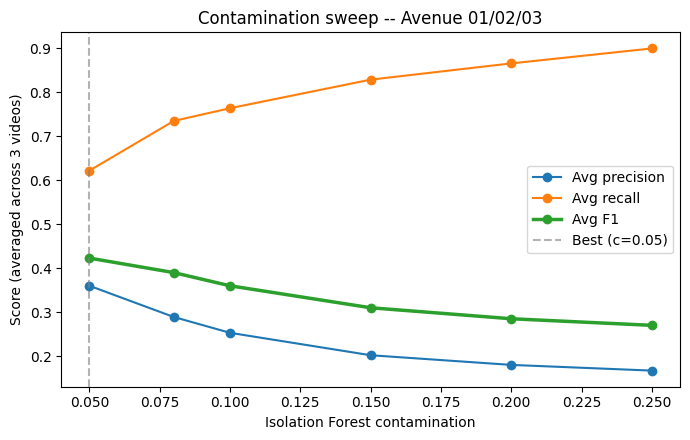

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_df["contamination"], sweep_df["avg_precision"], marker="o", label="Avg precision")
ax.plot(sweep_df["contamination"], sweep_df["avg_recall"], marker="o", label="Avg recall")
ax.plot(sweep_df["contamination"], sweep_df["avg_f1"], marker="o", label="Avg F1", linewidth=2.5)
ax.axvline(best["contamination"], color="gray", linestyle="--", alpha=0.6, label=f"Best (c={best['contamination']})")
ax.set_xlabel("Isolation Forest contamination")
ax.set_ylabel("Score (averaged across 3 videos)")
ax.set_title("Contamination sweep -- Avenue 01/02/03")
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/contamination_sweep_chart.png", dpi=150)
plt.show()

## 17. Extending the sweep lower

F1 was still climbing toward the *low* end of the last grid (0.423 at contamination=0.05, and falling at every step above it) -- that means the peak wasn't inside the tested range, not that 0.05 is actually optimal. Reusing the same `cache` from Section 16 (no need to re-run tracking), extending the grid down toward the low single digits.

In [37]:
contamination_grid_v2 = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.08]
sweep_rows_v2 = []

for c in contamination_grid_v2:
    video_scores = []
    for vid, d in cache.items():
        X = d["frame_feats"][["inst_speed", "inst_direction_change", "size_ratio"]].fillna(0)
        if len(X) == 0:
            continue
        iso = IsolationForest(contamination=c, random_state=42)
        flags = iso.fit_predict(X)

        n_pred_frames = int(d["tracks_df"]["frame"].max()) + 1
        pred = np.zeros(n_pred_frames, dtype=bool)
        for f, flag in zip(d["frame_feats"]["frame"], flags):
            if flag == -1:
                pred[int(f)] = True

        n = min(len(d["gt"]), n_pred_frames)
        y_true = d["gt"][:n].astype(int)
        y_pred = pred[:n].astype(int)

        video_scores.append({
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

    avg = pd.DataFrame(video_scores)[["precision", "recall", "f1"]].mean()
    sweep_rows_v2.append({
        "contamination": c,
        "avg_precision": round(float(avg["precision"]), 3),
        "avg_recall": round(float(avg["recall"]), 3),
        "avg_f1": round(float(avg["f1"]), 3),
    })

# Combine with the original grid so the full curve (0.01 -> 0.25) is visible in one table
sweep_df_full = pd.concat([pd.DataFrame(sweep_rows_v2), sweep_df], ignore_index=True)
sweep_df_full = sweep_df_full.drop_duplicates(subset="contamination").sort_values("contamination").reset_index(drop=True)
print(sweep_df_full)

best_v2 = sweep_df_full.loc[sweep_df_full["avg_f1"].idxmax()]
print("\nBest contamination by average F1 (full range):", best_v2.to_dict())
sweep_df_full.to_csv(f"{SAVE_DIR}/contamination_sweep_full.csv", index=False)

    contamination  avg_precision  avg_recall  avg_f1
0            0.01          0.407       0.173   0.227
1            0.02          0.421       0.338   0.345
2            0.03          0.429       0.496   0.423
3            0.04          0.391       0.566   0.428
4            0.05          0.360       0.622   0.423
5            0.06          0.331       0.667   0.413
6            0.08          0.289       0.735   0.390
7            0.10          0.253       0.764   0.360
8            0.15          0.202       0.829   0.310
9            0.20          0.180       0.866   0.285
10           0.25          0.167       0.900   0.270

Best contamination by average F1 (full range): {'contamination': 0.04, 'avg_precision': 0.391, 'avg_recall': 0.566, 'avg_f1': 0.428}


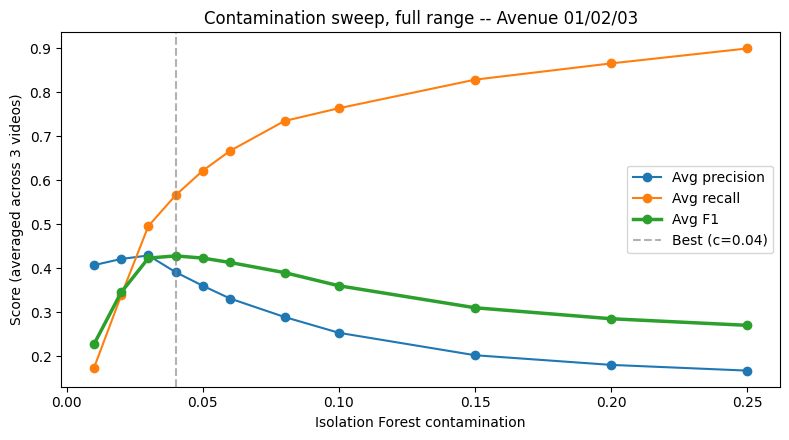

In [38]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sweep_df_full["contamination"], sweep_df_full["avg_precision"], marker="o", label="Avg precision")
ax.plot(sweep_df_full["contamination"], sweep_df_full["avg_recall"], marker="o", label="Avg recall")
ax.plot(sweep_df_full["contamination"], sweep_df_full["avg_f1"], marker="o", label="Avg F1", linewidth=2.5)
ax.axvline(best_v2["contamination"], color="gray", linestyle="--", alpha=0.6, label=f"Best (c={best_v2['contamination']})")
ax.set_xlabel("Isolation Forest contamination")
ax.set_ylabel("Score (averaged across 3 videos)")
ax.set_title("Contamination sweep, full range -- Avenue 01/02/03")
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/contamination_sweep_full_chart.png", dpi=150)
plt.show()